# CC3092 - Hoja de trabajo #2: Transformers y mecanismos de atención

**Universidad del Valle de Guatemala**  
**Deep Learning y Sistemas Inteligentes - Sección 20**  
**Mia Alejandra Fuentes Mérida - 23775**

Este notebook implementa y analiza atención en PyTorch, BERT y GPT-2. Genera automáticamente las figuras y los valores necesarios para completar el PDF de máximo 5 páginas.

> **Nota del enunciado:** el PDF entregado salta de la sección 5 a la 7; no aparece la sección 6/6.1 ni el ejercicio manual mencionado en la tabla de entregables. Por eso este notebook cubre todo lo que sí está especificado y no inventa ese inciso faltante.

## 0. Instalación y configuración
En Google Colab basta ejecutar la siguiente celda. No hay entrenamiento; BERT-base y GPT-2 se usan solo en inferencia, por lo que CPU funciona, aunque GPU acelera la ejecución.

In [1]:
%pip -q install "transformers>=4.45,<5" pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 33.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.29.0 requires huggingface-hub<3.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import os, math, time, json, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)
print("Dispositivo:", device)
print("PyTorch:", torch.__version__)

Dispositivo: cuda
PyTorch: 2.11.0+cu130


## 1. Verificación del escalamiento $1/\sqrt{d_k}$
Si los componentes de $q$ y $k$ son independientes, con media 0 y varianza 1, entonces

$$q\cdot k=\sum_{i=1}^{d_k}q_i k_i,\qquad Var(q\cdot k)=d_k.$$

Dividir entre $\sqrt{d_k}$ deja la varianza aproximadamente en 1 y evita logits excesivos que saturen la softmax.

In [3]:
def verificar_varianza_escalamiento(dk=64, muestras=50_000):
    q = torch.randn(muestras, dk)
    k = torch.randn(muestras, dk)
    dots = (q * k).sum(dim=-1)
    scaled = dots / math.sqrt(dk)
    return {
        "d_k": dk,
        "var(q·k) teórica": dk,
        "var(q·k) empírica": dots.var(unbiased=True).item(),
        "var(escalado) esperada": 1.0,
        "var(escalado) empírica": scaled.var(unbiased=True).item(),
    }

pd.DataFrame([verificar_varianza_escalamiento(dk) for dk in [16, 64, 256]])

,d_k,var(q·k) teórica,var(q·k) empírica,var(escalado) esperada,var(escalado) empírica
0,16,16,16.017168,1.0,1.001073
1,64,64,63.737682,1.0,0.995901
2,256,256,258.559113,1.0,1.009997


## 2. APIs de atención en PyTorch
Se muestran los argumentos solicitados: `scaled_dot_product_attention`, `MultiheadAttention`, `TransformerEncoderLayer` y la máscara causal.

In [4]:
B, N, D, H = 2, 8, 32, 4
x = torch.randn(B, N, D)

# 2.1 Multi-head attention, conservando pesos por cabeza
mha = nn.MultiheadAttention(embed_dim=D, num_heads=H, batch_first=True)
out, weights = mha(x, x, x, need_weights=True, average_attn_weights=False)
print("MHA output:", tuple(out.shape))
print("Pesos por cabeza:", tuple(weights.shape), "= batch × heads × n × n")

# 2.2 Scaled dot-product attention
Dh = D // H
q = torch.randn(B, H, N, Dh)
k = torch.randn(B, H, N, Dh)
v = torch.randn(B, H, N, Dh)
y = F.scaled_dot_product_attention(q, k, v, dropout_p=0.0, is_causal=False)
print("SDPA output:", tuple(y.shape))

# 2.3 Encoder Post-LN vs Pre-LN
post_ln = nn.TransformerEncoderLayer(d_model=D, nhead=H, dim_feedforward=64,
                                     dropout=0.1, batch_first=True, norm_first=False)
pre_ln = nn.TransformerEncoderLayer(d_model=D, nhead=H, dim_feedforward=64,
                                    dropout=0.1, batch_first=True, norm_first=True)
print("Post-LN norm_first:", post_ln.norm_first)
print("Pre-LN norm_first:", pre_ln.norm_first)

# 2.4 Máscara causal
mask = nn.Transformer.generate_square_subsequent_mask(6)
print(mask)

MHA output: (2, 8, 32)
Pesos por cabeza: (2, 4, 8, 8) = batch × heads × n × n
SDPA output: (2, 4, 8, 8)
Post-LN norm_first: False
Pre-LN norm_first: True
tensor([[0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0.]])


### Parámetros: ¿cambia el número de parámetros con el número de cabezas?
Mientras `embed_dim` se mantenga fijo y sea divisible entre `num_heads`, PyTorch usa proyecciones cuyo tamaño total depende de `embed_dim`, no del número de cabezas.

In [5]:
def n_params(m):
    return sum(p.numel() for p in m.parameters())

rows = []
for h in [1, 2, 4, 8]:
    m = nn.MultiheadAttention(embed_dim=64, num_heads=h, batch_first=True)
    rows.append({"heads": h, "head_dim": 64 // h, "parámetros": n_params(m)})
pd.DataFrame(rows)

,heads,head_dim,parámetros
0,1,64,16640
1,2,32,16640
2,4,16,16640
3,8,8,16640


## 3. Escalamiento y costo computacional
Se grafica el crecimiento teórico de la matriz $n	imes n$ y se hace un benchmark pequeño con la implementación explícita `softmax(QKᵀ/√d)V`. El benchmark no pretende comparar hardware entre computadoras; sirve para verificar la tendencia.

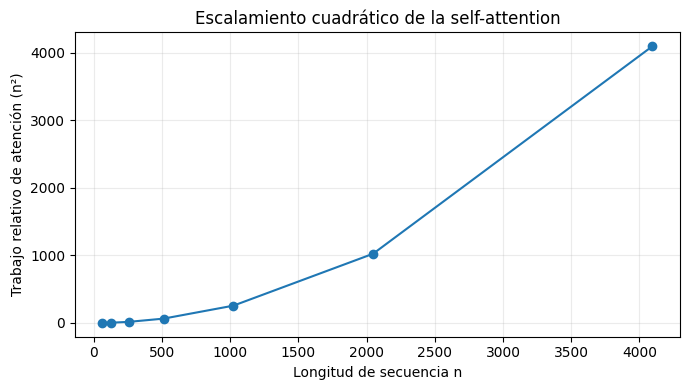

In [6]:
lengths = np.array([64, 128, 256, 512, 1024, 2048, 4096])
relative_work = (lengths / lengths[0]) ** 2

plt.figure(figsize=(7, 4))
plt.plot(lengths, relative_work, marker="o")
plt.xlabel("Longitud de secuencia n")
plt.ylabel("Trabajo relativo de atención (n²)")
plt.title("Escalamiento cuadrático de la self-attention")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "escalamiento_cuadratico.png", dpi=180)
plt.show()

,n,GB_12_heads_1_layer
0,128,0.000732
1,512,0.011719
2,2048,0.187500
3,8192,3.000000
4,32768,48.000000
5,100000,447.034836


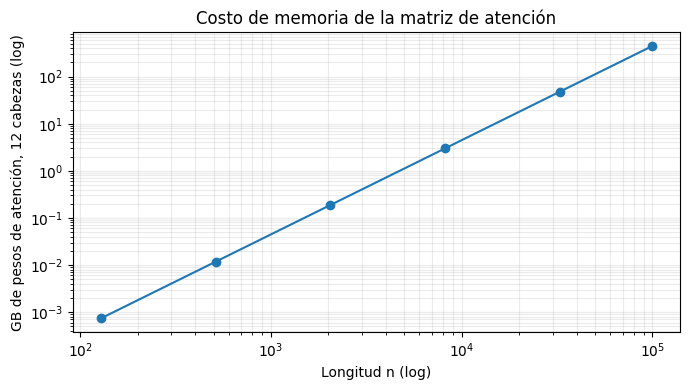

Para 100,000 tokens: 447.0 GB por capa solo para los pesos de 12 cabezas FP32.


In [7]:
# Memoria de los pesos de atención para 12 cabezas en float32, una capa.
lengths_mem = np.array([128, 512, 2048, 8192, 32768, 100_000], dtype=float)
mem_gb = 12 * lengths_mem**2 * 4 / (1024**3)
mem_df = pd.DataFrame({"n": lengths_mem.astype(int), "GB_12_heads_1_layer": mem_gb})
display(mem_df)

plt.figure(figsize=(7, 4))
plt.loglog(lengths_mem, mem_gb, marker="o")
plt.xlabel("Longitud n (log)")
plt.ylabel("GB de pesos de atención, 12 cabezas (log)")
plt.title("Costo de memoria de la matriz de atención")
plt.grid(which="both", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "costo_memoria_atencion.png", dpi=180)
plt.show()

print(f"Para 100,000 tokens: {mem_gb[-1]:.1f} GB por capa solo para los pesos de 12 cabezas FP32.")

,n,tiempo_ms_mediana,MiB_scores
0,64,0.293589,0.125
1,128,0.222784,0.500
2,256,0.218726,2.000
3,512,0.624422,8.000
4,1024,1.730168,32.000


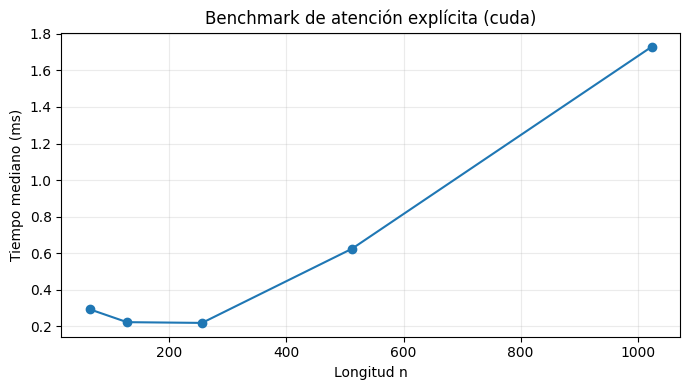

In [8]:
def manual_attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))
    probs = scores.softmax(dim=-1)
    return probs @ v

def benchmark_attention():
    B, H, Dh = 1, 8, 64
    test_lengths = [64, 128, 256, 512, 1024] if device.type == "cuda" else [64, 128, 256, 384]
    rows = []
    for n in test_lengths:
        q = torch.randn(B, H, n, Dh, device=device)
        k = torch.randn_like(q)
        v = torch.randn_like(q)
        # warm-up
        with torch.inference_mode():
            _ = manual_attention(q, k, v)
        if device.type == "cuda": torch.cuda.synchronize()
        samples = []
        for _ in range(3):
            t0 = time.perf_counter()
            with torch.inference_mode():
                _ = manual_attention(q, k, v)
            if device.type == "cuda": torch.cuda.synchronize()
            samples.append((time.perf_counter() - t0) * 1000)
        mem_mib = B * H * n * n * 4 / 1024**2
        rows.append({"n": n, "tiempo_ms_mediana": np.median(samples), "MiB_scores": mem_mib})
    return pd.DataFrame(rows)

bench = benchmark_attention()
display(bench)

plt.figure(figsize=(7, 4))
plt.plot(bench["n"], bench["tiempo_ms_mediana"], marker="o")
plt.xlabel("Longitud n")
plt.ylabel("Tiempo mediano (ms)")
plt.title(f"Benchmark de atención explícita ({device.type})")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "benchmark_atencion.png", dpi=180)
plt.show()

## 4. Carga de BERT y GPT-2 con atenciones
Se usa exactamente la idea indicada en el enunciado: `output_attentions=True` y `attn_implementation="eager"`.

In [9]:
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained(
    "bert-base-uncased", output_attentions=True, attn_implementation="eager"
).to(device).eval()

tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained(
    "gpt2", output_attentions=True, attn_implementation="eager"
).to(device).eval()

print("BERT:", bert.config.num_hidden_layers, "capas,", bert.config.num_attention_heads, "cabezas")
print("GPT-2:", gpt2.config.n_layer, "capas,", gpt2.config.n_head, "cabezas")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

BERT: 12 capas, 12 cabezas
GPT-2: 12 capas, 12 cabezas


## 5. Funciones auxiliares para extraer y graficar atención

In [10]:
def pretty_token(t):
    return t.replace("Ġ", "▁").replace("Ċ", "↵")

def get_attentions(model, tokenizer, text):
    inputs = tokenizer(text, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.inference_mode():
        out = model(**inputs, output_attentions=True)
    tokens = [pretty_token(t) for t in tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])]
    attn = tuple(a.detach().float().cpu() for a in out.attentions)
    return tokens, attn

def head_matrix(attentions, layer, head):
    return attentions[layer][0, head].numpy()

def plot_head(tokens, attentions, layer, head, model_name, filename=None):
    A = head_matrix(attentions, layer, head)
    plt.figure(figsize=(max(6, len(tokens)*0.42), max(5, len(tokens)*0.38)))
    im = plt.imshow(A, aspect="auto", interpolation="nearest")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.title(f"{model_name} - capa {layer+1}, cabeza {head+1}")
    plt.tight_layout()
    if filename:
        plt.savefig(FIG_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

PUNCT = {".", ",", ";", ":", "!", "?"}

def head_pattern_scores(A, tokens, bidirectional=True):
    A = np.asarray(A)
    scores = {}
    scores["misma palabra/diagonal"] = float(np.diag(A).mean())
    if len(tokens) > 1:
        scores["token anterior"] = float(np.diag(A, k=-1).mean())
        if bidirectional:
            scores["token siguiente"] = float(np.diag(A, k=1).mean())
    scores["primer token"] = float(A[:, 0].mean())
    scores["último token"] = float(A[:, -1].mean())
    punct_idx = [i for i,t in enumerate(tokens) if t.strip("▁") in PUNCT]
    if punct_idx:
        scores["puntuación"] = float(A[:, punct_idx].mean())
    return scores

def summarize_head(tokens, attentions, layer, head, bidirectional=True):
    A = head_matrix(attentions, layer, head)
    scores = head_pattern_scores(A, tokens, bidirectional)
    best = max(scores, key=scores.get)
    return {"layer": layer+1, "head": head+1, "patrón dominante (heurístico)": best, "score": scores[best], **scores}

## 6. Mapas de calor: 4 cabezas de capas distintas
La oración puede cambiarse. Se generan cuatro mapas para BERT y cuatro para GPT-2, junto con una clasificación heurística del patrón dominante.

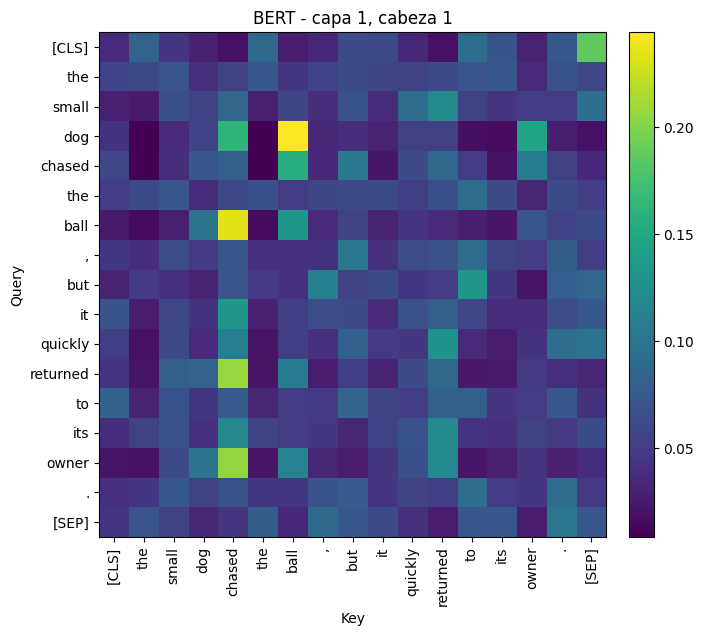

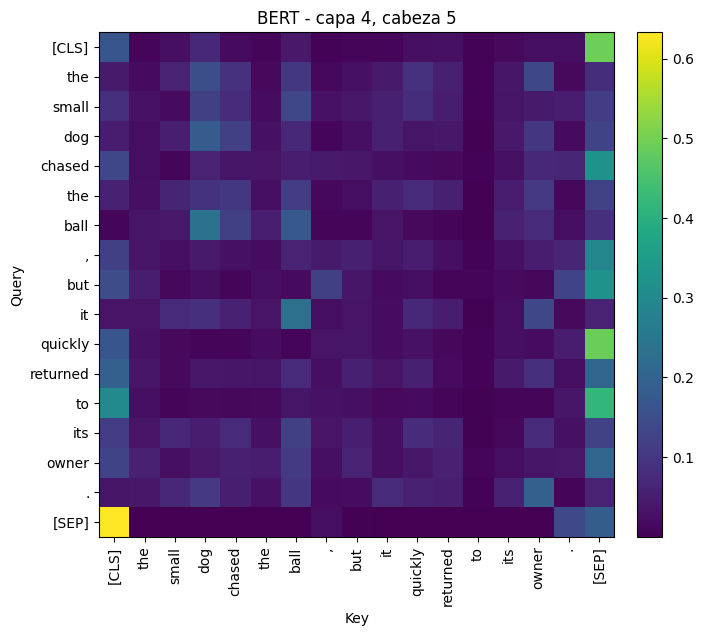

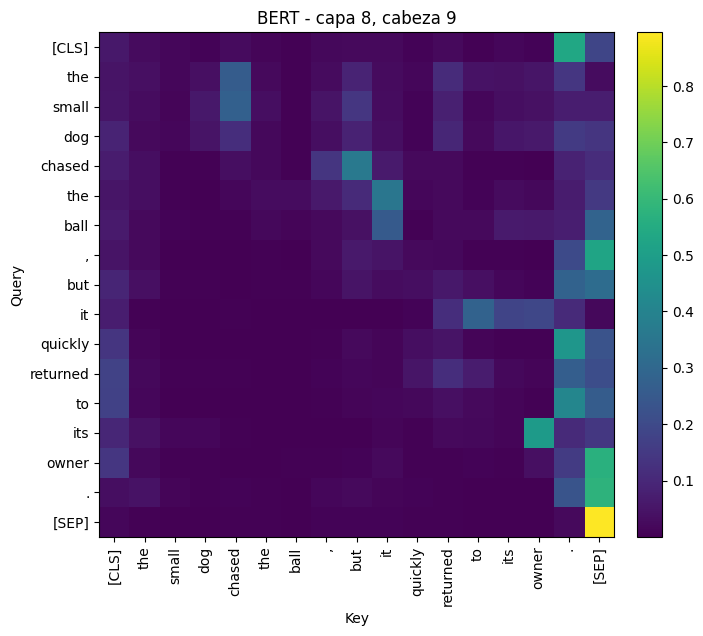

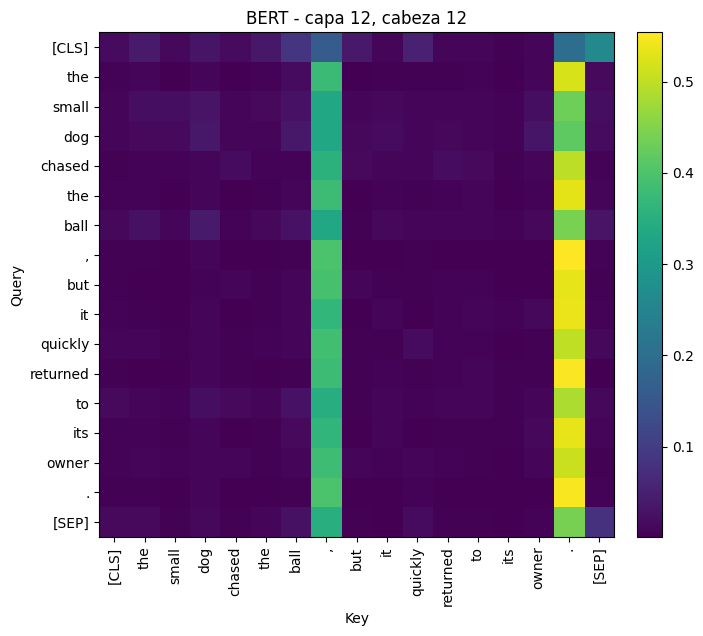

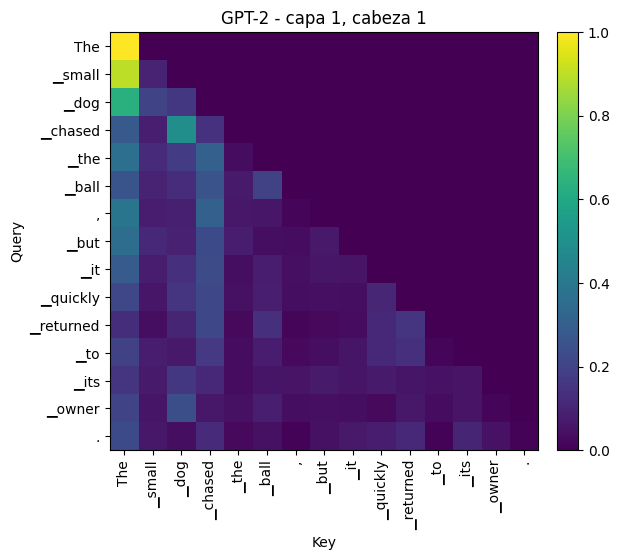

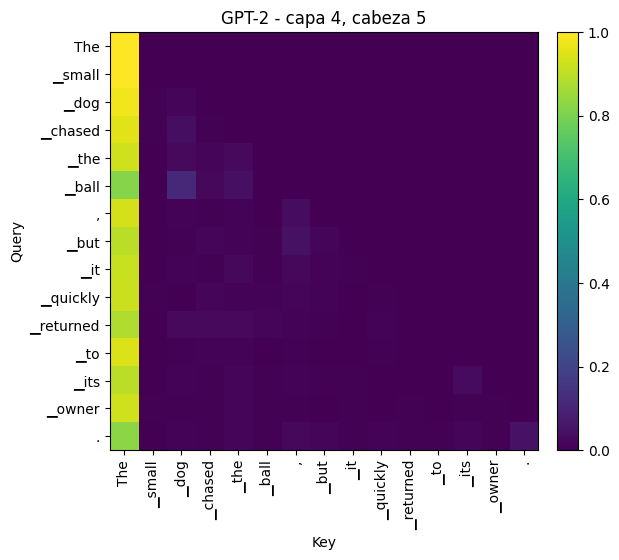

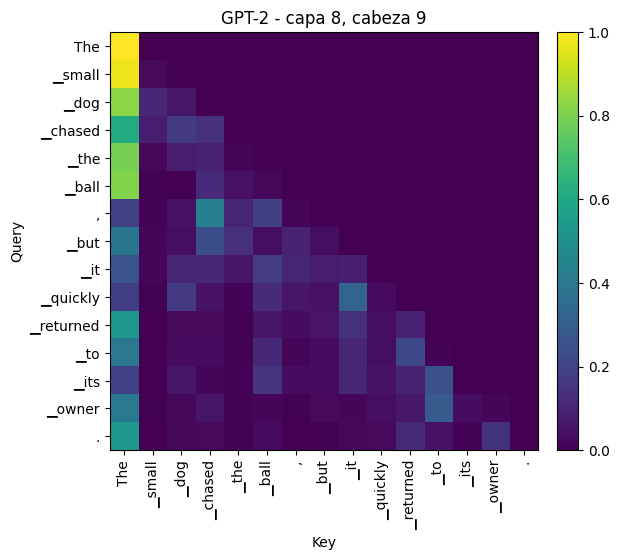

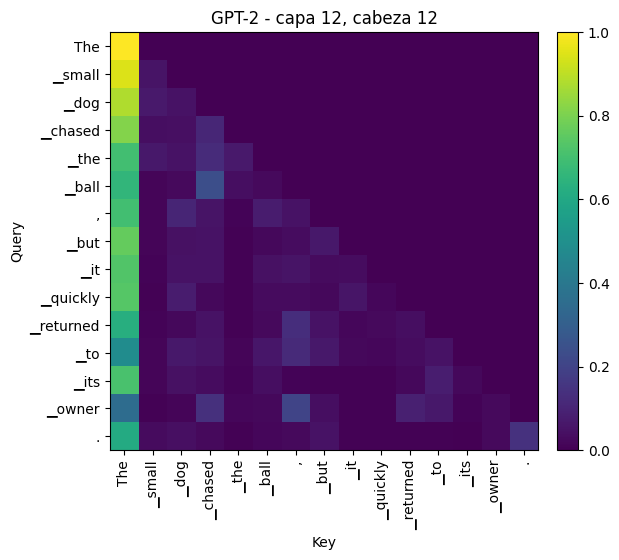

,modelo,layer,head,patrón dominante (heurístico),score
0,BERT,1,1,último token,0.065779
1,BERT,4,5,último token,0.219264
2,BERT,8,9,último token,0.278134
3,BERT,12,12,puntuación,0.419663
4,GPT-2,1,1,primer token,0.373191
5,GPT-2,4,5,primer token,0.921832
6,GPT-2,8,9,primer token,0.540217
7,GPT-2,12,12,primer token,0.714392


In [11]:
sentence = "The small dog chased the ball, but it quickly returned to its owner."
bert_tokens, bert_attn = get_attentions(bert, tok_bert, sentence)
gpt_tokens, gpt_attn = get_attentions(gpt2, tok_gpt2, sentence)

bert_sel = [(0,0), (3,4), (7,8), (11,11)]
gpt_sel  = [(0,0), (3,4), (7,8), (11,11)]

rows = []
for layer, head in bert_sel:
    plot_head(bert_tokens, bert_attn, layer, head, "BERT", f"bert_L{layer+1}_H{head+1}.png")
    rows.append({"modelo":"BERT", **summarize_head(bert_tokens, bert_attn, layer, head, True)})
for layer, head in gpt_sel:
    plot_head(gpt_tokens, gpt_attn, layer, head, "GPT-2", f"gpt2_L{layer+1}_H{head+1}.png")
    rows.append({"modelo":"GPT-2", **summarize_head(gpt_tokens, gpt_attn, layer, head, False)})

patterns_df = pd.DataFrame(rows)
display(patterns_df[["modelo","layer","head","patrón dominante (heurístico)","score"]])

## 7. BERT: contraste de “it” entre *tired* y *wide*
Se recorren **todas** las capas y cabezas. El criterio estricto solicitado es:

- En *tired*: `it → animal` > `it → street`.
- En *wide*: `it → street` > `it → animal`.

Si no aparece una cabeza que cumpla ambos criterios, el notebook lo dice explícitamente y muestra la mejor aproximación según el margen combinado.

Se encontró al menos una cabeza con cruce estricto.


,layer,head,tired_it_animal,tired_it_street,wide_it_animal,wide_it_street,strict_cross,combined_margin
82,7,11,0.284269,0.067086,0.011940,0.590173,True,0.795415
106,9,11,0.675520,0.000408,0.309091,0.259248,False,0.625270
116,10,9,0.454436,0.002548,0.022884,0.044949,True,0.473953
108,10,1,0.607947,0.002260,0.255371,0.074436,False,0.424752
128,11,9,0.564287,0.001494,0.244925,0.078053,False,0.395920
100,9,5,0.241659,0.014476,0.046217,0.209082,True,0.390048
58,5,11,0.332989,0.095223,0.167439,0.288258,True,0.358584
126,11,7,0.714113,0.008001,0.489658,0.107740,False,0.324193
109,10,2,0.432198,0.016040,0.341447,0.216410,False,0.291120
103,9,8,0.205207,0.050253,0.061114,0.194367,True,0.288208



Mejor cabeza:


,layer,head,tired_it_animal,tired_it_street,wide_it_animal,wide_it_street,strict_cross,combined_margin
82,7,11,0.284269,0.067086,0.01194,0.590173,True,0.795415


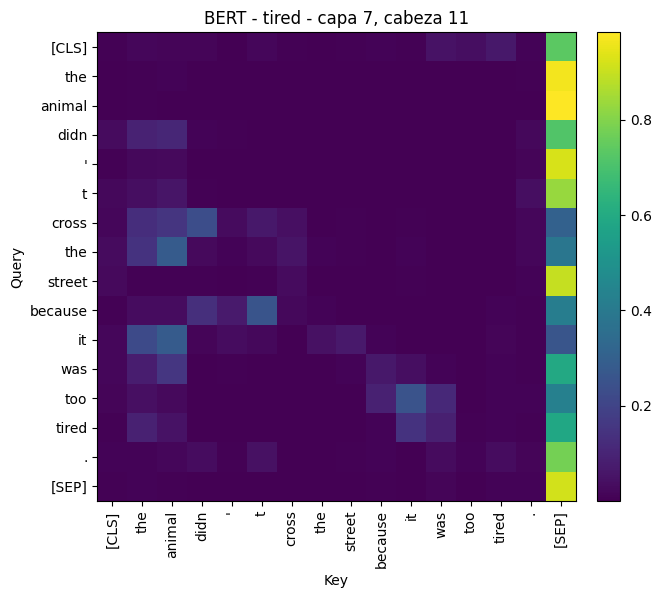

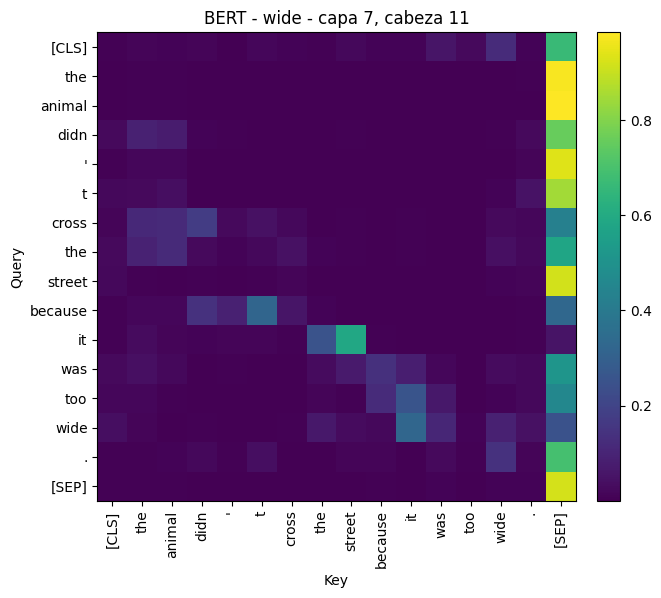

In [12]:
sent_tired = "The animal didn't cross the street because it was too tired."
sent_wide  = "The animal didn't cross the street because it was too wide."

def bert_target_scores(text):
    tokens, attn = get_attentions(bert, tok_bert, text)
    # Los tres objetivos son tokens únicos en estas frases con bert-base-uncased.
    def idx_exact(word):
        hits = [i for i,t in enumerate(tokens) if t == word]
        if len(hits) != 1:
            raise ValueError(f"No se encontró un único token {word!r}. Tokens: {tokens}")
        return hits[0]
    return tokens, attn, idx_exact("it"), idx_exact("animal"), idx_exact("street")

tok_t, att_t, it_t, animal_t, street_t = bert_target_scores(sent_tired)
tok_w, att_w, it_w, animal_w, street_w = bert_target_scores(sent_wide)

candidates = []
for L in range(len(att_t)):
    heads = att_t[L].shape[1]
    for H in range(heads):
        At = att_t[L][0,H]
        Aw = att_w[L][0,H]
        ta = float(At[it_t, animal_t]); ts = float(At[it_t, street_t])
        wa = float(Aw[it_w, animal_w]);  ws = float(Aw[it_w, street_w])
        strict = (ta > ts) and (ws > wa)
        margin = (ta - ts) + (ws - wa)
        candidates.append({
            "layer": L+1, "head": H+1,
            "tired_it_animal": ta, "tired_it_street": ts,
            "wide_it_animal": wa, "wide_it_street": ws,
            "strict_cross": strict, "combined_margin": margin
        })

coref_df = pd.DataFrame(candidates).sort_values("combined_margin", ascending=False)
strict_df = coref_df[coref_df["strict_cross"]]
if len(strict_df):
    best = strict_df.iloc[0]
    print("Se encontró al menos una cabeza con cruce estricto.")
else:
    best = coref_df.iloc[0]
    print("No se encontró cruce estricto; se reporta la mejor aproximación sin falsear el resultado.")

display(coref_df.head(10))
print("\nMejor cabeza:")
display(best.to_frame().T)

L, H = int(best["layer"])-1, int(best["head"])-1
plot_head(tok_t, att_t, L, H, "BERT - tired", "bert_coref_tired.png")
plot_head(tok_w, att_w, L, H, "BERT - wide", "bert_coref_wide.png")

## 8. GPT-2: causalidad y *attention sinks*
Primero se verifica que no haya masa de atención por encima de la diagonal. Después se calcula cuánto peso medio recibe el primer token por capa. Se muestran dos medidas: incluyendo la primera consulta (trivialmente solo puede mirar al primer token) y excluyéndola.

,layer,max_attention_future,mean_first_token_all_queries,mean_first_token_excluding_q0
0,1,0.0,0.316947,0.260025
1,2,0.0,0.495087,0.453011
2,3,0.0,0.486768,0.443999
3,4,0.0,0.597361,0.563808
4,5,0.0,0.627070,0.595993
5,6,0.0,0.760936,0.741014
6,7,0.0,0.733369,0.711150
7,8,0.0,0.828108,0.813784
8,9,0.0,0.790693,0.773250
9,10,0.0,0.828124,0.813801


Máximo peso sobre tokens futuros: 0.000e+00
Matriz triangular inferior verificada: True


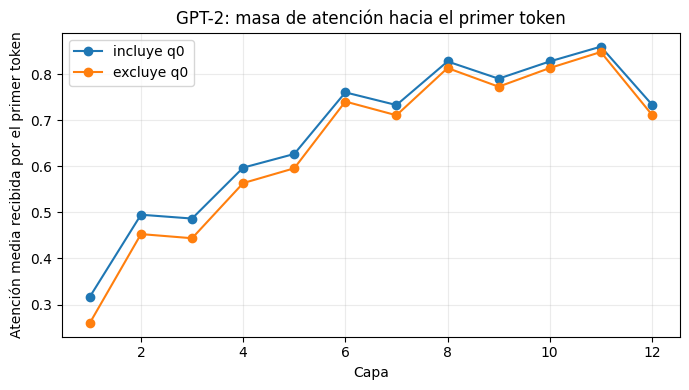

In [13]:
gpt_sentence = "The animal didn't cross the street because it was too tired."
gpt_tokens2, gpt_attn2 = get_attentions(gpt2, tok_gpt2, gpt_sentence)

causal_rows = []
for L, a in enumerate(gpt_attn2):
    A = a[0]  # heads × q × k
    upper = torch.triu(A, diagonal=1)
    causal_rows.append({
        "layer": L+1,
        "max_attention_future": float(upper.abs().max()),
        "mean_first_token_all_queries": float(A[:,:,0].mean()),
        "mean_first_token_excluding_q0": float(A[:,1:,0].mean()) if A.shape[1] > 1 else np.nan,
    })
causal_df = pd.DataFrame(causal_rows)
display(causal_df)

max_future = causal_df["max_attention_future"].max()
print(f"Máximo peso sobre tokens futuros: {max_future:.3e}")
print("Matriz triangular inferior verificada:", bool(max_future < 1e-6))

plt.figure(figsize=(7,4))
plt.plot(causal_df["layer"], causal_df["mean_first_token_all_queries"], marker="o", label="incluye q0")
plt.plot(causal_df["layer"], causal_df["mean_first_token_excluding_q0"], marker="o", label="excluye q0")
plt.xlabel("Capa")
plt.ylabel("Atención media recibida por el primer token")
plt.title("GPT-2: masa de atención hacia el primer token")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "gpt2_attention_sink.png", dpi=180)
plt.show()

## 9. Entropía promedio de atención por capa
Se usa entropía normalizada entre 0 y 1. En BERT se normaliza por `log(n)`. En GPT-2 cada posición solo puede atender a su prefijo, por lo que se normaliza por `log(i+1)` y se omite la primera consulta, cuyo soporte tiene tamaño 1.

,layer,BERT_entropy_norm,GPT2_entropy_norm
0,1,0.758974,0.675000
1,2,0.648363,0.710782
2,3,0.570048,0.682299
3,4,0.610580,0.522253
4,5,0.552483,0.452525
5,6,0.430155,0.407685
6,7,0.476474,0.462434
7,8,0.439841,0.333477
8,9,0.540858,0.444356
9,10,0.543231,0.341333


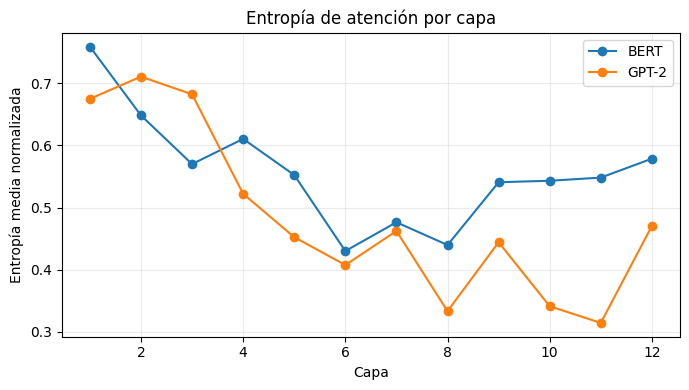

Pendiente BERT: -0.01297 -> más concentrada
Pendiente GPT-2: -0.03109 -> más concentrada


In [14]:
def normalized_entropy_per_layer(attentions, causal=False):
    vals = []
    eps = 1e-12
    for a in attentions:
        A = a[0].clamp_min(eps)  # heads × q × k
        H = -(A * A.log()).sum(dim=-1)  # heads × q
        n = A.shape[-1]
        if causal:
            denom = torch.log(torch.arange(1, n+1, dtype=torch.float32))
            valid = denom > 0
            Hn = H[:, valid] / denom[valid]
        else:
            Hn = H / math.log(n)
        vals.append(float(Hn.mean()))
    return np.array(vals)

bert_entropy = normalized_entropy_per_layer(bert_attn, causal=False)
gpt_entropy = normalized_entropy_per_layer(gpt_attn, causal=True)

entropy_df = pd.DataFrame({
    "layer": np.arange(1, len(bert_entropy)+1),
    "BERT_entropy_norm": bert_entropy,
    "GPT2_entropy_norm": gpt_entropy,
})
display(entropy_df)

plt.figure(figsize=(7,4))
plt.plot(entropy_df["layer"], entropy_df["BERT_entropy_norm"], marker="o", label="BERT")
plt.plot(entropy_df["layer"], entropy_df["GPT2_entropy_norm"], marker="o", label="GPT-2")
plt.xlabel("Capa")
plt.ylabel("Entropía media normalizada")
plt.title("Entropía de atención por capa")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "entropia_por_capa.png", dpi=180)
plt.show()

x = entropy_df["layer"].to_numpy()
slope_bert = np.polyfit(x, bert_entropy, 1)[0]
slope_gpt = np.polyfit(x, gpt_entropy, 1)[0]
print(f"Pendiente BERT: {slope_bert:+.5f} ->", "más difusa" if slope_bert>0 else "más concentrada")
print(f"Pendiente GPT-2: {slope_gpt:+.5f} ->", "más difusa" if slope_gpt>0 else "más concentrada")

## 10. Resumen automático para copiar al documento
Esta celda reúne los resultados concretos de la ejecución para evitar transcribirlos a mano.

In [15]:
best_dict = best.to_dict()
summary_lines = []
summary_lines.append("RESULTADOS PARA EL INFORME")
summary_lines.append("="*60)
summary_lines.append(f"Dispositivo usado: {device}")
summary_lines.append(f"GPT-2 - máximo peso sobre la diagonal: {max_future:.3e}")
summary_lines.append(f"GPT-2 - máscara causal triangular inferior verificada: {max_future < 1e-6}")
summary_lines.append("")
summary_lines.append("BERT - prueba tired/wide:")
summary_lines.append(f"  capa {int(best_dict['layer'])}, cabeza {int(best_dict['head'])}, cruce estricto={bool(best_dict['strict_cross'])}")
summary_lines.append(f"  tired: it→animal={best_dict['tired_it_animal']:.6f}, it→street={best_dict['tired_it_street']:.6f}")
summary_lines.append(f"  wide:  it→animal={best_dict['wide_it_animal']:.6f}, it→street={best_dict['wide_it_street']:.6f}")
summary_lines.append("")
summary_lines.append(f"Entropía BERT: pendiente={slope_bert:+.6f} ({'más difusa' if slope_bert>0 else 'más concentrada'} hacia capas profundas)")
summary_lines.append(f"Entropía GPT-2: pendiente={slope_gpt:+.6f} ({'más difusa' if slope_gpt>0 else 'más concentrada'} hacia capas profundas)")
summary_lines.append("")
summary_lines.append("Promedio de atención al primer token por capa (GPT-2, excluyendo q0):")
for _, r in causal_df.iterrows():
    summary_lines.append(f"  capa {int(r.layer):02d}: {r.mean_first_token_excluding_q0:.6f}")
summary_lines.append("")
summary_lines.append("Patrones heurísticos de las 8 cabezas graficadas:")
for _, r in patterns_df.iterrows():
    summary_lines.append(f"  {r['modelo']} L{int(r['layer'])} H{int(r['head'])}: {r['patrón dominante (heurístico)']} (score={r['score']:.4f})")

summary = "\n".join(summary_lines)
print(summary)
Path("resumen_resultados.txt").write_text(summary, encoding="utf-8")

# Guardar tablas como CSV y comprimir figuras.
coref_df.to_csv("resultado_coreferencia_bert.csv", index=False)
causal_df.to_csv("resultado_gpt2_causal_sink.csv", index=False)
entropy_df.to_csv("resultado_entropia.csv", index=False)
patterns_df.to_csv("resultado_patrones_cabezas.csv", index=False)
shutil.make_archive("figuras_transformers", "zip", FIG_DIR)
print("\nArchivos listos: resumen_resultados.txt, CSVs y figuras_transformers.zip")

RESULTADOS PARA EL INFORME
Dispositivo usado: cuda
GPT-2 - máximo peso sobre la diagonal: 0.000e+00
GPT-2 - máscara causal triangular inferior verificada: True

BERT - prueba tired/wide:
  capa 7, cabeza 11, cruce estricto=True
  tired: it→animal=0.284269, it→street=0.067086
  wide:  it→animal=0.011940, it→street=0.590173

Entropía BERT: pendiente=-0.012975 (más concentrada hacia capas profundas)
Entropía GPT-2: pendiente=-0.031093 (más concentrada hacia capas profundas)

Promedio de atención al primer token por capa (GPT-2, excluyendo q0):
  capa 01: 0.260025
  capa 02: 0.453011
  capa 03: 0.443999
  capa 04: 0.563808
  capa 05: 0.595993
  capa 06: 0.741014
  capa 07: 0.711150
  capa 08: 0.813784
  capa 09: 0.773250
  capa 10: 0.813801
  capa 11: 0.848637
  capa 12: 0.712443

Patrones heurísticos de las 8 cabezas graficadas:
  BERT L1 H1: último token (score=0.0658)
  BERT L4 H5: último token (score=0.2193)
  BERT L8 H9: último token (score=0.2781)
  BERT L12 H12: puntuación (score=0.

## 11. Texto guía para la discusión final

- **Paralelismo:** a diferencia de una RNN, la capa Transformer no necesita esperar el estado oculto del token anterior; QKᵀ y las proyecciones se implementan como operaciones matriciales paralelas.
- **Camino entre tokens:** dentro de self-attention, dos posiciones se conectan directamente en una capa; en una RNN la información debe atravesar múltiples pasos temporales.
- **Costo cuadrático:** esa conectividad global tiene precio `O(n²)` en los pares de atención.
- **Especialización:** use los mapas y la tabla `patterns_df` como evidencia visual, pero no asuma que toda cabeza es indispensable; algunas pueden ser redundantes.
- **Interpretabilidad:** Jain & Wallace (2019) advierten que los pesos de atención no equivalen necesariamente a importancia causal; Wiegreffe & Pinter (2019) sostienen que la utilidad explicativa depende de la definición y de pruebas apropiadas.
- **100,000 tokens:** la matriz estándar contiene `10^10` pares por cabeza. Considere ventanas/global (Longformer), aproximaciones lineales (Performer), jerarquías/segmentación o implementaciones exactas más eficientes en memoria como FlashAttention.

### Referencias principales
Vaswani et al. (2017), Bahdanau et al. (2014), Luong et al. (2015), Xiong et al. (2020), Su et al. (2021), Dao et al. (2022), Beltagy et al. (2020), Choromanski et al. (2020), Jain & Wallace (2019), Wiegreffe & Pinter (2019), Xiao et al. (2023), documentación oficial de PyTorch y Hugging Face Transformers.